In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
# Load your dataset
df = pd.read_csv('./individual_stocks_5yr/MMC_data.csv')
df = df.dropna()
print(f"Initial rows loaded: {len(df)}")
print(df.head())

Initial rows loaded: 1259
         date   open   high    low  close    volume Name
0  2013-02-08  36.50  36.56  36.27  36.55   2555112  MMC
1  2013-02-11  36.56  36.58  36.29  36.35   2980656  MMC
2  2013-02-12  35.78  36.04  34.43  36.02  10119802  MMC
3  2013-02-13  36.03  36.37  35.88  36.30   4309083  MMC
4  2013-02-14  36.10  36.30  36.00  36.07   3421396  MMC


In [5]:
# Feature Engineering: Calculate daily behaviors
# Volatility: How wild were the price swings during the day?
df['Volatility'] = (df['high'] - df['low']) / df['open']

# Daily Return: Did the stock close higher or lower than it opened?
df['Daily_Return'] = (df['close'] - df['open']) / df['open']

print("Sample of engineered features:")
print(df[['date', 'open', 'high', 'low', 'close', 'Volatility', 'Daily_Return']].head())

Sample of engineered features:
         date   open   high    low  close  Volatility  Daily_Return
0  2013-02-08  36.50  36.56  36.27  36.55    0.007945      0.001370
1  2013-02-11  36.56  36.58  36.29  36.35    0.007932     -0.005744
2  2013-02-12  35.78  36.04  34.43  36.02    0.044997      0.006708
3  2013-02-13  36.03  36.37  35.88  36.30    0.013600      0.007494
4  2013-02-14  36.10  36.30  36.00  36.07    0.008310     -0.000831


In [7]:
# Select your features and drop any rows with missing data
features = ['Volatility', 'volume', 'Daily_Return']
df_clean = df.dropna(subset=features).copy()
X = df_clean[features]
print(f"Rows after dropping NaNs: {len(df_clean)}")

Rows after dropping NaNs: 1259


In [9]:
# Standardize the data (Crucial step!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data after standardization (first 5 rows):")
print(X_scaled[:5])
print(df.head())

Data after standardization (first 5 rows):
[[-0.66811131  0.56066062  0.0697067 ]
 [-0.67022495  1.06254468 -0.79664203]
 [ 5.33799469  9.48241109  0.71976184]
 [ 0.24849136  2.6292836   0.81549549]
 [-0.60893793  1.58235082 -0.19832505]]
         date   open   high    low  close    volume Name  Volatility  \
0  2013-02-08  36.50  36.56  36.27  36.55   2555112  MMC    0.007945   
1  2013-02-11  36.56  36.58  36.29  36.35   2980656  MMC    0.007932   
2  2013-02-12  35.78  36.04  34.43  36.02  10119802  MMC    0.044997   
3  2013-02-13  36.03  36.37  35.88  36.30   4309083  MMC    0.013600   
4  2013-02-14  36.10  36.30  36.00  36.07   3421396  MMC    0.008310   

   Daily_Return  
0      0.001370  
1     -0.005744  
2      0.006708  
3      0.007494  
4     -0.000831  


In [12]:
# Apply K-Means Clustering
# Guessing there are 3 main market regimes
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)
print(df.head())

         date   open   high    low  close    volume Name  Volatility  \
0  2013-02-08  36.50  36.56  36.27  36.55   2555112  MMC    0.007945   
1  2013-02-11  36.56  36.58  36.29  36.35   2980656  MMC    0.007932   
2  2013-02-12  35.78  36.04  34.43  36.02  10119802  MMC    0.044997   
3  2013-02-13  36.03  36.37  35.88  36.30   4309083  MMC    0.013600   
4  2013-02-14  36.10  36.30  36.00  36.07   3421396  MMC    0.008310   

   Daily_Return  
0      0.001370  
1     -0.005744  
2      0.006708  
3      0.007494  
4     -0.000831  


In [13]:
# Analyze the Results
# Let's look at the average stats for each cluster so we can name them
cluster_summary = df_clean.groupby('Cluster')[features].mean()
print("Average Stats per Market Regime:")
print(cluster_summary)
print("\nNumber of days in each regime:")
print(df_clean['Cluster'].value_counts())

Average Stats per Market Regime:
         Volatility        volume  Daily_Return
Cluster                                        
0          0.009440  1.742487e+06      0.001024
1          0.016514  2.760963e+06     -0.009273
2          0.020008  2.955440e+06      0.012758

Number of days in each regime:
Cluster
0    874
1    218
2    167
Name: count, dtype: int64


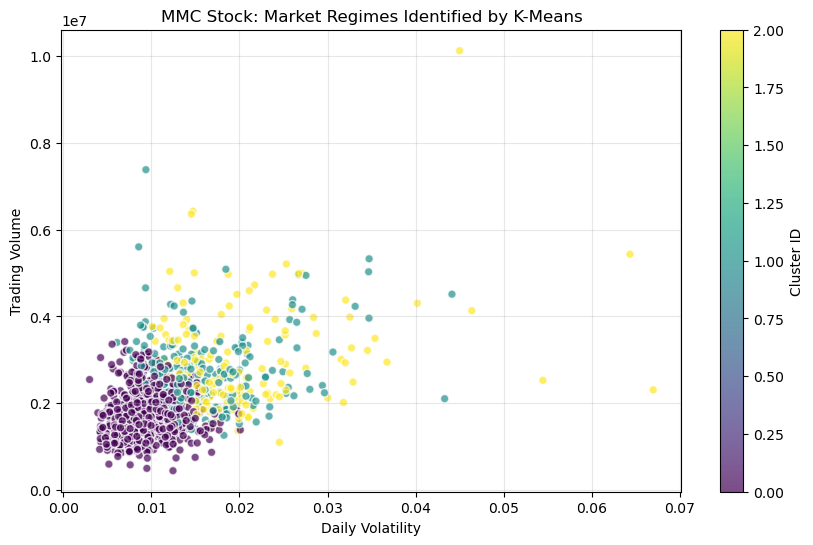

In [14]:
# Visualize the Regimes
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_clean['Volatility'],
    df_clean['volume'],
    c=df_clean['Cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='w'
)

plt.xlabel('Daily Volatility')
plt.ylabel('Trading Volume')
plt.title('MMC Stock: Market Regimes Identified by K-Means')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()